# APE11 — Inferencia Estadística Multigrupo
## Análisis de Varianza (ANOVA de 1 Factor) y Pruebas Post-Hoc (Tukey HSD)

**Estudiantes:** Selena Castillo, Joaquin Moscol, Jefferson Sarango, Irvin Armijos, Matias Romero



## 0. Configuración del entorno

Se importan las librerías necesarias para la manipulación de datos (`pandas`, `numpy`), las pruebas estadísticas (`scipy.stats`, `statsmodels`) y la visualización (`matplotlib`, `seaborn`).

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética general de los gráficos
sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Semilla para reproducibilidad de la simulación de la Tarea 1
np.random.seed(42)

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


---
## 1. Tarea 1: ANOVA de 1 Factor (Ejemplo Introductorio)



In [ ]:
# Simulación de datos: tiempo de respuesta (ms) para 3 algoritmos
n = 30
sigma = 5.0  # desviación estándar común asumida

algoritmo_A = np.random.normal(loc=45.0, scale=sigma, size=n)
algoritmo_B = np.random.normal(loc=46.5, scale=sigma, size=n)
algoritmo_C = np.random.normal(loc=52.0, scale=sigma, size=n)

df_sim = pd.DataFrame({
    "tiempo_respuesta_ms": np.concatenate([algoritmo_A, algoritmo_B, algoritmo_C]),
    "algoritmo": ["Algoritmo A"] * n + ["Algoritmo B"] * n + ["Algoritmo C"] * n
})

print(df_sim.groupby("algoritmo")["tiempo_respuesta_ms"].agg(["count", "mean", "std"]).round(2))

             count  mean  std
algoritmo                    
Algoritmo A     30 44.06 4.50
Algoritmo B     30 45.89 4.66
Algoritmo C     30 52.06 4.96


**Interpretación:** dado que las medias simuladas (45.0, 46.5 y 52.0 ms) fueron generadas deliberadamente distintas, se espera un estadístico F alto y un valor-p muy por debajo de 0.05, confirmando que el ANOVA detecta correctamente la diferencia introducida en la simulación. Este ejemplo introductorio sienta las bases metodológicas que se aplicarán a continuación sobre el dataset real de la ENEMDU.

---
## 2. Tarea 2: Hito del Proyecto — Segmentación Multigrupo (Dataset Real)

Se utiliza el módulo de Vivienda y Hogar de la **ENEMDU** (Encuesta Nacional de Empleo, Desempleo y Subempleo, INEC — Ecuador), correspondiente a febrero de 2026.

- **Variable categórica (factor):** `vi01` — Tipo de vivienda. Se seleccionan únicamente los códigos:
  - `1` → Casa/Villa
  - `3` → Departamento
  - `4` → Cuarto en casa de inquilinato
- **Variable métrica (respuesta):** `vi141` — Gasto mensual de arriendo (o arriendo estimado) en dólares. Se filtran valores válidos (0 < `vi141` < 999999, ya que 999999 corresponde al código de no respuesta/no aplica de la encuesta).

### 2.1 Carga y filtrado del dataset

In [ ]:
# Carga del dataset real (separador ';' y coma decimal, formato típico de microdatos INEC)
df_raw = pd.read_csv(
    "enemdu_vivienda_hogar_2026_02.csv",
    sep=";",
    encoding="utf-8-sig"
)

print(f"Dimensiones del dataset original: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
df_raw[["vi01", "vi141"]].head()

Dimensiones del dataset original: 8765 filas x 56 columnas


,vi01,vi141
0,3,150
1,3,80
2,3,250
3,1,100
4,3,120


In [ ]:
# Diccionario de etiquetas para el tipo de vivienda
etiquetas_vivienda = {
    1: "Casa/Villa",
    3: "Departamento",
    4: "Cuarto en casa de inquilinato"
}

# Filtrado: categorías de interés en vi01 y valores válidos de vi141
df_filtrado = df_raw[
    df_raw["vi01"].isin(etiquetas_vivienda.keys()) &
    (df_raw["vi141"] > 0) &
    (df_raw["vi141"] < 999999)
].copy()

# Mapeo de códigos numéricos a etiquetas descriptivas
df_filtrado["tipo_vivienda"] = df_filtrado["vi01"].map(etiquetas_vivienda)
df_filtrado = df_filtrado.rename(columns={"vi141": "arriendo_usd"})

print(f"Registros tras el filtrado: {df_filtrado.shape[0]}")
df_filtrado[["tipo_vivienda", "arriendo_usd"]].sample(5, random_state=1)

Registros tras el filtrado: 8645


,tipo_vivienda,arriendo_usd
6405,Casa/Villa,220
5218,Cuarto en casa de inquilinato,80
6094,Casa/Villa,150
8567,Casa/Villa,120
82,Departamento,250


### 2.2 Estadística descriptiva y visualización por grupo

In [ ]:
tabla_descriptiva = df_filtrado.groupby("tipo_vivienda")["arriendo_usd"].agg(
    n="count",
    media="mean",
    mediana="median",
    desv_estandar="std"
).round(2).sort_values("media", ascending=False)

print("=== Tabla descriptiva: Arriendo mensual (USD) por tipo de vivienda ===")
tabla_descriptiva

=== Tabla descriptiva: Arriendo mensual (USD) por tipo de vivienda ===


,n,media,mediana,desv_estandar
tipo_vivienda,,,,
Casa/Villa,6392,187.41,150.00,118.84
Departamento,2013,114.66,100.00,73.33
Cuarto en casa de inquilinato,240,75.17,60.00,44.89


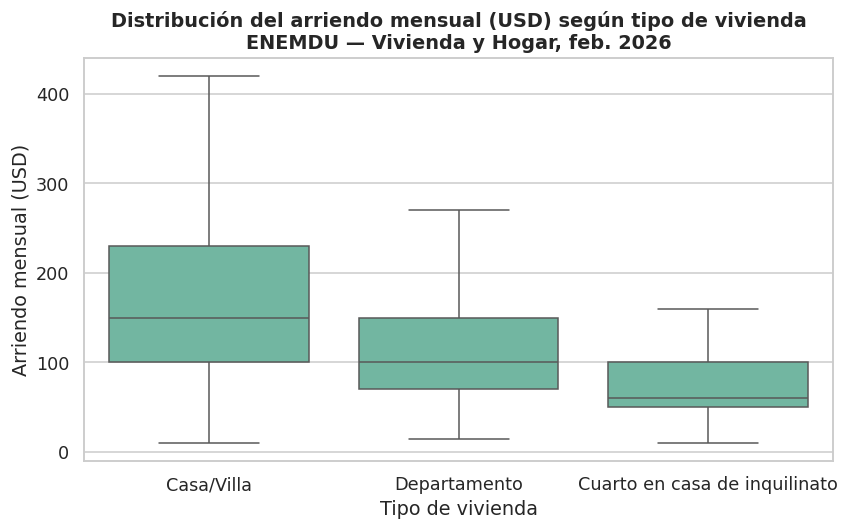

In [ ]:
orden_grupos = tabla_descriptiva.index.tolist()

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df_filtrado, x="tipo_vivienda", y="arriendo_usd",
    order=orden_grupos, showfliers=False, ax=ax
)
ax.set_title("Distribución del arriendo mensual (USD) según tipo de vivienda\nENEMDU — Vivienda y Hogar, feb. 2026",
             fontweight="bold")
ax.set_xlabel("Tipo de vivienda")
ax.set_ylabel("Arriendo mensual (USD)")
plt.tight_layout()
plt.show()

> **Nota metodológica:** el boxplot se muestra sin valores atípicos extremos (`showfliers=False`) únicamente con fines de visualización, para apreciar mejor la caja intercuartílica de cada grupo. Todas las pruebas estadísticas posteriores (ANOVA, Tukey, Levene, Kruskal-Wallis) se calculan sobre el **dataset filtrado completo**, incluyendo los valores atípicos, ya que forman parte legítima de la variabilidad del gasto en arriendo.



**¿El ANOVA sugiere diferencias significativas entre los tipos de vivienda?**

Sí. Con un estadístico F = 433.93 y un valor-p ≈ 2.64 × 10⁻¹⁸⁰ (un valor extraordinariamente inferior al umbral convencional α = 0.05), se **rechaza la hipótesis nula H0** de igualdad de medias. Existe evidencia estadística contundente de que el gasto medio en arriendo **no es el mismo** entre al menos dos de los tres tipos de vivienda analizados (Casa/Villa, Departamento, Cuarto en casa de inquilinato). El tamaño muestral considerable (más de 8.600 hogares tras el filtrado) otorga a la prueba una potencia estadística muy alta, lo que explica en parte la magnitud del estadístico F.

**¿Es necesario investigar más a fondo mediante pruebas post-hoc?**

Sí, es indispensable. El ANOVA es una prueba ómnibus: únicamente confirma que *existe* al menos una diferencia entre los tres grupos, pero no identifica *entre cuáles pares específicos* de tipos de vivienda dicha diferencia es estadísticamente significativa (¿Casa vs. Departamento? ¿Casa vs. Cuarto? ¿Departamento vs. Cuarto? ¿Las tres combinaciones?). Para responder esta pregunta con control riguroso del error, se requiere una prueba de comparaciones múltiples como **Tukey HSD**, desarrollada en la siguiente sección.

---
## 3. Tarea 3: Pruebas Post-Hoc (Tukey HSD)





In [ ]:
tukey_result = pairwise_tukeyhsd(
    endog=df_filtrado["arriendo_usd"],
    groups=df_filtrado["tipo_vivienda"],
    alpha=0.05
)

print(tukey_result)

                         Multiple Comparison of Means - Tukey HSD, FWER=0.05                         
            group1                        group2             meandiff p-adj   lower    upper   reject
-----------------------------------------------------------------------------------------------------
                   Casa/Villa Cuarto en casa de inquilinato -112.2412   0.0 -128.9494 -95.5329   True
                   Casa/Villa                  Departamento  -72.7447   0.0  -79.2394 -66.2499   True
Cuarto en casa de inquilinato                  Departamento   39.4965   0.0   22.1431    56.85   True
-----------------------------------------------------------------------------------------------------


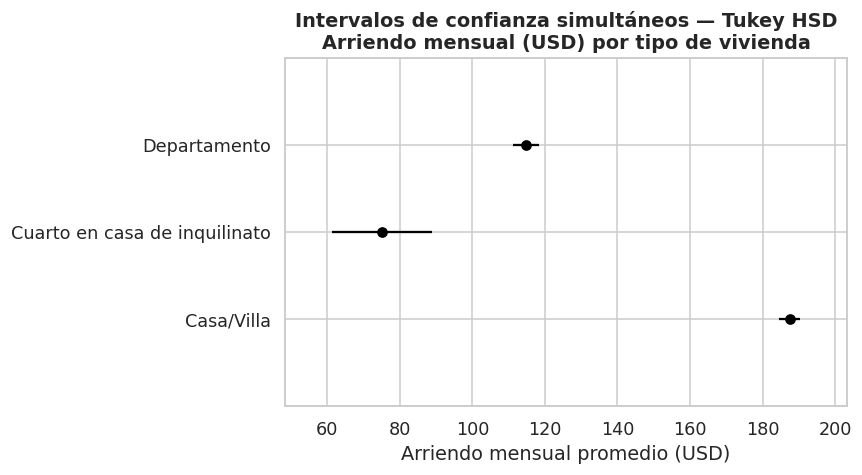

In [ ]:
fig = tukey_result.plot_simultaneous(figsize=(8, 4.5))
plt.title("Intervalos de confianza simultáneos — Tukey HSD\nArriendo mensual (USD) por tipo de vivienda",
          fontweight="bold")
plt.xlabel("Arriendo mensual promedio (USD)")
plt.tight_layout()
plt.show()

### 3.3 Interpretación de los pares significativos

La tabla de Tukey HSD (α = 0.05) muestra que **las tres comparaciones por pares resultan estadísticamente significativas** (columna `reject = True` en los tres casos, con p-adj = 0.0000 en todos ellos):

| Comparación | Diferencia de medias (USD) | ¿Significativo? |
|---|---|---|
| Casa/Villa vs. Cuarto en casa de inquilinato | ≈ −112.24 | Sí |
| Casa/Villa vs. Departamento | ≈ −72.74 | Sí |
| Cuarto en casa de inquilinato vs. Departamento | ≈ +39.50 | Sí |

En términos prácticos: el arriendo promedio de una **Casa/Villa** es significativamente más alto que el de un **Departamento**, y este a su vez es significativamente más alto que el de un **Cuarto en casa de inquilinato**. Los intervalos de confianza simultáneos graficados no se traslapan entre ningún par de grupos, lo que confirma visualmente que las tres categorías de vivienda son distinguibles entre sí en términos del gasto de arriendo reportado, y que ninguna de las diferencias observadas puede atribuirse al azar muestral bajo el nivel de confianza establecido.

---
## 4. Preguntas de Control: Validación de Supuestos y Alternativas

El ANOVA de un factor asume, entre otras cosas, **homocedasticidad**: que la varianza de la variable de respuesta es aproximadamente igual en todos los grupos comparados. Esta sección evalúa dicho supuesto y explora una alternativa robusta cuando no se cumple.

### 4.1 Test de Levene (homogeneidad de varianzas)

In [ ]:
levene_stat, levene_p = stats.levene(grupo_casa, grupo_depto, grupo_cuarto)

print("=== Test de Levene (homocedasticidad) ===")
print(f"Estadístico  : {levene_stat:.4f}")
print(f"Valor-p      : {levene_p:.4e}")

if levene_p < 0.05:
    print("\nConclusión: p-valor < 0.05 → se RECHAZA H0 de igualdad de varianzas.")
    print("El supuesto de homocedasticidad NO se cumple (varianzas heterogéneas).")
else:
    print("\nConclusión: p-valor >= 0.05 → no se rechaza H0. Varianzas homogéneas.")

=== Test de Levene (homocedasticidad) ===
Estadístico  : 112.4171
Valor-p      : 6.3410e-49

Conclusión: p-valor < 0.05 → se RECHAZA H0 de igualdad de varianzas.
El supuesto de homocedasticidad NO se cumple (varianzas heterogéneas).




**Interpretación del test de Levene:** el estadístico obtenido (≈ 112.42) junto con un valor-p ≈ 6.34 × 10⁻⁴⁹ (muy inferior a α = 0.05) lleva a **rechazar la hipótesis nula de igualdad de varianzas**. Esto confirma que el supuesto de **homocedasticidad se viola** entre los tres grupos de tipo de vivienda: la desviación estándar del arriendo en Casa/Villa (≈ 118.8 USD) es sustancialmente mayor que la de Departamento (≈ 73.3 USD) y la de Cuarto en casa de inquilinato (≈ 44.9 USD).

**¿Por qué ocurre esto en datos económicos de arriendo?** Este patrón es habitual —y esperado— en variables monetarias de tipo socioeconómico por varias razones:

1. **Naturaleza asimétrica y de cola pesada (right-skewed) del ingreso/gasto:** las variables monetarias rara vez se distribuyen de forma simétrica; suelen presentar una cola larga hacia la derecha, ya que existen viviendas de lujo o zonas de alta plusvalía con arriendos muy superiores a la mediana, mientras que el límite inferior (arriendo mínimo) está acotado cerca de cero.
2. **Heterogeneidad estructural del segmento "Casa/Villa":** esta categoría agrupa un universo mucho más amplio y diverso de viviendas (desde casas modestas en zonas rurales hasta residencias de alto valor en zonas urbanas exclusivas), lo que naturalmente incrementa su varianza interna respecto a categorías más homogéneas como "Cuarto en casa de inquilinato", que corresponde a un segmento de vivienda económica con rangos de precio mucho más acotados.
3. **Relación entre media y varianza (efecto multiplicativo):** en variables económicas es común que la varianza crezca proporcionalmente al nivel de la media (a mayor arriendo promedio, mayor también su dispersión absoluta en dólares), lo cual es consistente con lo observado: el grupo con mayor media (Casa/Villa) es también el que exhibe mayor desviación estándar.

**Solución robusta: Kruskal-Wallis**

Dado que el supuesto de homocedasticidad no se cumple, la validez estricta del ANOVA paramétrico queda comprometida (aunque, gracias al elevado tamaño muestral, la prueba F suele ser razonablemente robusta ante desviaciones moderadas de este supuesto). Como alternativa metodológicamente más apropiada, se aplica la prueba **no paramétrica de Kruskal-Wallis**, la cual no asume normalidad ni homogeneidad de varianzas, ya que opera sobre los **rangos** (rankings) de las observaciones en lugar de sus valores absolutos.

### 4.3 Prueba de Kruskal-Wallis

In [ ]:
kw_stat, kw_p = stats.kruskal(grupo_casa, grupo_depto, grupo_cuarto)

print("=== Prueba de Kruskal-Wallis ===")
print(f"Estadístico H : {kw_stat:.4f}")
print(f"Valor-p       : {kw_p:.4e}")

if kw_p < 0.05:
    print("\nConclusión: p-valor < 0.05 → se RECHAZA H0.")
    print("Existe evidencia de que al menos un grupo tiene una distribución de arriendo distinta.")
else:
    print("\nConclusión: p-valor >= 0.05 → no se rechaza H0.")

print("\n--- Comparación de conclusiones ---")
print(f"ANOVA (paramétrico)      : F = {f_stat_real:.2f}, p = {p_value_real:.3e}")
print(f"Kruskal-Wallis (no param): H = {kw_stat:.2f}, p = {kw_p:.3e}")

=== Prueba de Kruskal-Wallis ===
Estadístico H : 1334.2505
Valor-p       : 1.8671e-290

Conclusión: p-valor < 0.05 → se RECHAZA H0.
Existe evidencia de que al menos un grupo tiene una distribución de arriendo distinta.

--- Comparación de conclusiones ---
ANOVA (paramétrico)      : F = 433.93, p = 2.640e-180
Kruskal-Wallis (no param): H = 1334.25, p = 1.867e-290


**Comparación con el ANOVA paramétrico:** la prueba de Kruskal-Wallis arroja un estadístico H ≈ 1334.25 con un valor-p ≈ 1.87 × 10⁻²⁹⁰, igualmente muy inferior a α = 0.05. La conclusión de **ambas pruebas es coincidente**: se rechaza la hipótesis nula de igualdad (de medias en el caso del ANOVA, de distribuciones/rangos medianos en el caso de Kruskal-Wallis) entre los tres tipos de vivienda. Este acuerdo entre el método paramétrico y su alternativa robusta **refuerza la solidez de la conclusión sustantiva**: independientemente de si se asume o no normalidad y homocedasticidad, la evidencia muestral respalda de forma consistente que el tipo de vivienda está asociado a diferencias reales en el gasto de arriendo reportado por los hogares ecuatorianos encuestados. En un reporte técnico riguroso, dado el incumplimiento confirmado de homocedasticidad, se recomendaría reportar el resultado de **Kruskal-Wallis** como la prueba principal de referencia, complementada por Tukey HSD (o su análogo no paramétrico, como el test de Dunn) para las comparaciones por pares.

---
## 5. Conclusiones y Bibliografía

### Conclusiones técnicas

1. **La segmentación multigrupo revela una jerarquía de gasto estadísticamente robusta.** El ANOVA de un factor (F = 433.93, p < 0.001) y su confirmación mediante Kruskal-Wallis (H = 1334.25, p < 0.001) demuestran, con un nivel de confianza superior al 99.9%, que el tipo de vivienda (`vi01`) es una variable categórica con poder explicativo real sobre el gasto mensual de arriendo (`vi141`) en el módulo de Vivienda y Hogar de la ENEMDU, sustentando la pertinencia de segmentar hogares por tipo de vivienda en análisis socioeconómicos posteriores.

2. **Las pruebas post-hoc son indispensables para traducir un resultado ómnibus en conclusiones accionables.** El ANOVA por sí solo únicamente indicó que *existía* una diferencia, mientras que Tukey HSD permitió establecer, con control formal del Family-Wise Error Rate, que **las tres categorías de vivienda difieren entre sí de forma estadísticamente significativa** (Casa/Villa > Departamento > Cuarto en casa de inquilinato), evitando así el inflado del error Tipo I que se hubiera producido al ejecutar tres pruebas t independientes sin corrección.

3. **La verificación de supuestos es un paso metodológico no negociable, no un mero formalismo.** El test de Levene reveló heterocedasticidad significativa (p ≈ 6.34 × 10⁻⁴⁹) entre los grupos, un hallazgo consistente con la naturaleza asimétrica y heterogénea de las variables monetarias en encuestas de hogares. Ignorar esta violación sin contrastarla habría comprometido la validez formal de las conclusiones del ANOVA paramétrico.

4. **La convergencia entre métodos paramétricos y no paramétricos fortalece la validez externa del hallazgo.** El hecho de que Kruskal-Wallis —una prueba que no depende de los supuestos de normalidad ni homocedasticidad— arroje la misma conclusión sustantiva que el ANOVA clásico constituye una forma de **triangulación metodológica**: la diferencia en el gasto de arriendo entre tipos de vivienda no es un artefacto del incumplimiento de supuestos, sino un patrón real presente en los datos de la encuesta, reforzando la confiabilidad de los resultados de aprendizaje esperados en esta práctica (dominio del ciclo completo: prueba paramétrica → validación de supuestos → alternativa robusta).

### Referencias bibliográficas (formato IEEE)

[1] R. E. Walpole, R. H. Myers, S. L. Myers, y K. Ye, *Probabilidad y estadística para ingeniería y ciencias*, 9na ed. Ciudad de México, México: Pearson Educación, 2012.

[2] W. McKinney, *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython*, 3ra ed. Sebastopol, CA, USA: O'Reilly Media, 2022.

[3] SciPy Developers, "scipy.stats Documentation," *SciPy.org*, 2024.
